In [26]:
import itertools
from paddle.vision.datasets import Cifar10,MNIST
import matplotlib.pyplot as plt
import numpy as np

In [27]:
cifar10_train, cifar10_test = Cifar10(mode= 'train',backend="cv2"), Cifar10(mode= 'test',backend="cv2")
mnist_train, mnist_test = MNIST(mode= 'train',backend="cv2"), MNIST(mode= 'test',backend="cv2")

print('Cifar10:',len(cifar10_train),len(cifar10_test))
print('MNIST:', len(mnist_train),len(mnist_test))

Cifar10: 50000 10000
MNIST: 60000 10000


In [28]:
for img, label in itertools.islice(iter(cifar10_train), 1):
    print(type(img),img.shape)
for img, label in itertools.islice(iter(mnist_train), 1):
    print(type(img),img.shape)

<class 'numpy.ndarray'> (32, 32, 3)
<class 'numpy.ndarray'> (28, 28)


# 复现完成

In [12]:
class DLMT:
    def __init__(self,imgsize,rise_v=100,max_v_add=256,max_v_mul=10):
        self.method_label ="DLMT"
        self.img_size = imgsize
        self.MAX_V_ADD,self.MAX_V_MUL = max_v_add,max_v_mul
        self.RISE_V = rise_v
        self.R_add = np.random.randint(1, self.MAX_V_ADD, size=self.img_size, dtype=np.uint16)
        self.R_mul = np.random.randint(1, self.MAX_V_MUL, size=self.img_size, dtype=np.uint16)
        
    def MAT(self,img):
        return (img + self.R_add)/(255*(1+self.MAX_V_ADD/256))

    def MMT(self,img):
        if self.img_size == (28,28):
            return (img / 255) * self.R_mul/(self.MAX_V_MUL-1)
        r = (img[:, :, 0] / 255) * self.R_mul[:, :, 0]/(self.MAX_V_MUL-1)
        g = (img[:, :, 1] / 255) * self.R_mul[:, :, 1]/(self.MAX_V_MUL-1)
        b = (img[:, :, 2] / 255) * self.R_mul[:, :, 2]/(self.MAX_V_MUL-1)
        return np.dstack((r, g, b))
    
    def Rise_MMT(self,img):
        img = img + self.RISE_V
        if self.img_size == (28,28):
            return (img)/(255+self.RISE_V-1) * (self.R_mul/(self.MAX_V_MUL-1))
        r = (img[:, :, 0])/(255+self.RISE_V-1) * (self.R_mul[:, :, 0]/(self.MAX_V_MUL-1))
        g = (img[:, :, 1])/(255+self.RISE_V-1) * (self.R_mul[:, :, 1]/(self.MAX_V_MUL-1))
        b = (img[:, :, 2])/(255+self.RISE_V-1) * (self.R_mul[:, :, 2]/(self.MAX_V_MUL-1))
        return np.dstack((r, g, b))

    def MAT_MMT(self,img):
        img = (img + self.R_add)/(255*(1+self.MAX_V_ADD/256))
        if self.img_size == (28,28):
            return img * self.R_mul/(self.MAX_V_MUL-1)
        r = (img[:, :, 0]) * self.R_mul[:, :, 0]/(self.MAX_V_MUL-1)
        g = (img[:, :, 1]) * self.R_mul[:, :, 1]/(self.MAX_V_MUL-1)
        b = (img[:, :, 2]) * self.R_mul[:, :, 2]/(self.MAX_V_MUL-1)
        return np.dstack((r, g, b)) 

    def MMT_MAT(self,img):
        if self.img_size == (28,28):
            return (img * self.R_mul/(self.MAX_V_MUL-1)+ self.R_add)/(255*(1+self.MAX_V_ADD/256))
        r = (img[:, :, 0] / 255) * self.R_mul[:, :, 0]/(self.MAX_V_MUL-1)
        g = (img[:, :, 1] / 255) * self.R_mul[:, :, 1]/(self.MAX_V_MUL-1)
        b = (img[:, :, 2] / 255) * self.R_mul[:, :, 2]/(self.MAX_V_MUL-1)
        img = np.dstack((r, g, b))
        return (img + self.R_add)/(255*(1+self.MAX_V_ADD/256))

In [13]:
dlmt = DLMT(imgsize=(28,28),rise_v=100,max_v_add=256,max_v_mul=10)
print(dlmt.method_label)

DLMT


## MAT

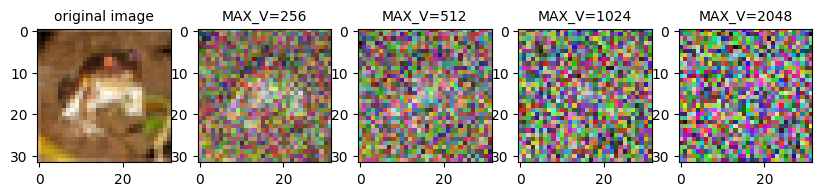

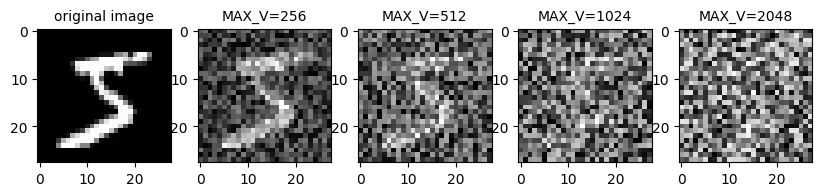

In [17]:
def show_mat(img,imgsize):
    fig = plt.figure(figsize=(10,10)) 
    ax1 = fig.add_subplot(1, 5, 1)  # 2行1列，第1个位置  
    plt.title('original image',fontsize=10)
    ax1.imshow(img,cmap='gray')

    img2mat = DLMT(imgsize=imgsize,max_v_add=256).MAT(img)
    ax2 = fig.add_subplot(1, 5, 2)
    plt.title('MAX_V=256',fontsize=10)
    ax2.imshow(img2mat,cmap='gray')

    img2mat = DLMT(imgsize=imgsize,max_v_add=512).MAT(img)
    ax2 = fig.add_subplot(1, 5, 3)
    plt.title('MAX_V=512',fontsize=10)
    ax2.imshow(img2mat,cmap='gray')

    img2mat = DLMT(imgsize=imgsize,max_v_add=1024).MAT(img)
    ax2 = fig.add_subplot(1, 5, 4)
    plt.title('MAX_V=1024',fontsize=10)
    ax2.imshow(img2mat,cmap='gray')

    img2mat = DLMT(imgsize=imgsize,max_v_add=2048).MAT(img)
    ax2 = fig.add_subplot(1, 5, 5)
    plt.title('MAX_V=2048',fontsize=10)
    ax2.imshow(img2mat,cmap='gray')

for img, label in itertools.islice(iter(cifar10_train), 1):
    img = img.astype(np.uint8)
    show_mat(img,imgsize=(32,32,3))
for img, label in itertools.islice(iter(mnist_train), 1):
    img = img.astype(np.uint8)
    show_mat(img,imgsize=(28,28))

## MMT

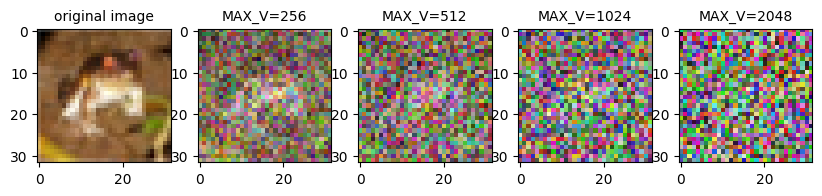

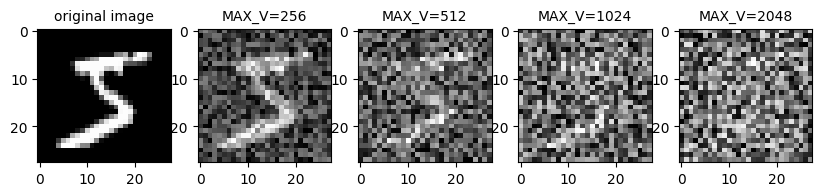

In [18]:
def show_mmt(img,imgsize):
    fig = plt.figure(figsize=(10,10)) 
    ax1 = fig.add_subplot(1, 5, 1)  # 2行1列，第1个位置  
    plt.title('original image',fontsize=10)
    ax1.imshow(img,cmap='gray')

    img2mmt = DLMT(imgsize=imgsize,max_v_mul=10).MMT(img)
    ax2 = fig.add_subplot(1, 5, 2)
    plt.title('MAX_V=10',fontsize=10)
    ax2.imshow(img2mmt,cmap='gray')
    
    img2mmt = DLMT(imgsize=imgsize,max_v_mul=100).MMT(img)
    ax2 = fig.add_subplot(1, 5, 3)
    plt.title('MAX_V=100',fontsize=10)
    ax2.imshow(img2mmt,cmap='gray')
    
    img2mmt = DLMT(imgsize=imgsize,max_v_mul=1000).MMT(img)
    ax2 = fig.add_subplot(1, 5, 4)
    plt.title('MAX_V=100',fontsize=10)
    ax2.imshow(img2mmt,cmap='gray')
    
    img2mmt = DLMT(imgsize=imgsize,max_v_mul=10000).MMT(img)
    ax2 = fig.add_subplot(1, 5, 5)
    plt.title('MAX_V=10000',fontsize=10)
    ax2.imshow(img2mmt,cmap='gray')
    
for img, label in itertools.islice(iter(cifar10_train), 1):
    img = img.astype(np.uint8)
    show_mat(img,imgsize=(32,32,3))
for img, label in itertools.islice(iter(mnist_train), 1):
    img = img.astype(np.uint8)
    show_mat(img,imgsize=(28,28))

## Rise + MMT

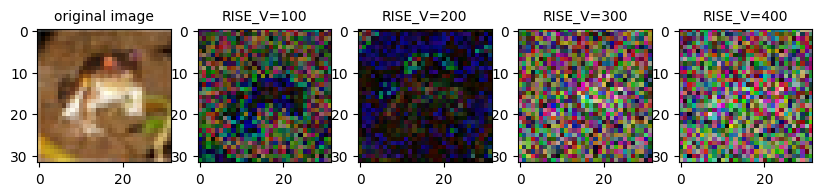

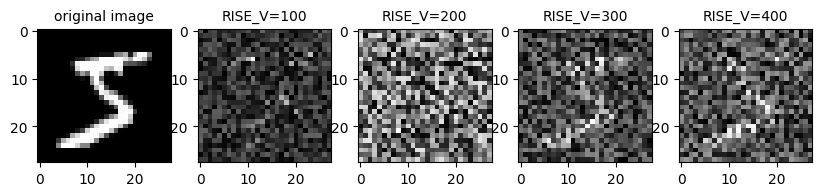

In [19]:
def show_rise_mmt(img,imgsize):
    fig = plt.figure(figsize=(10,10)) 
    ax1 = fig.add_subplot(1, 5, 1)  # 2行1列，第1个位置  
    plt.title('original image',fontsize=10)
    ax1.imshow(img,cmap='gray')

    img2rise_mmt = DLMT(imgsize=imgsize,rise_v=100,max_v_mul=1000).Rise_MMT(img)
    ax2 = fig.add_subplot(1, 5, 2)
    plt.title('RISE_V=100',fontsize=10)
    ax2.imshow(img2rise_mmt,cmap='gray')
    
    img2rise_mmt = DLMT(imgsize=imgsize,rise_v=200,max_v_mul=1000).Rise_MMT(img)
    ax2 = fig.add_subplot(1, 5, 3)
    plt.title('RISE_V=200',fontsize=10)
    ax2.imshow(img2rise_mmt,cmap='gray')
    
    img2rise_mmt = DLMT(imgsize=imgsize,rise_v=300,max_v_mul=1000).Rise_MMT(img)
    ax2 = fig.add_subplot(1, 5, 4)
    plt.title('RISE_V=300',fontsize=10)
    ax2.imshow(img2rise_mmt,cmap='gray')
    
    img2rise_mmt = DLMT(imgsize=imgsize,rise_v=400,max_v_mul=1000).Rise_MMT(img)
    ax2 = fig.add_subplot(1, 5, 5)
    plt.title('RISE_V=400',fontsize=10)
    ax2.imshow(img2rise_mmt,cmap='gray')
    
for img, label in itertools.islice(iter(cifar10_train), 1):
    img = img.astype(np.uint8)
    show_rise_mmt(img,imgsize=(32,32,3))
for img, label in itertools.islice(iter(mnist_train), 1):
    img = img.astype(np.uint8)
    show_rise_mmt(img,imgsize=(28,28))

## MAT + MMT

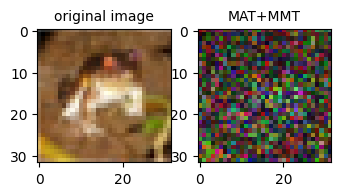

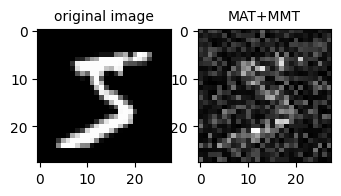

In [20]:
def show_mat_mmt(img,imgsize):
    fig = plt.figure(figsize=(10,10)) 
    ax1 = fig.add_subplot(1, 5, 1)  # 2行1列，第1个位置  
    plt.title('original image',fontsize=10)
    ax1.imshow(img,cmap='gray')
    
    img2mat_mmt = DLMT(imgsize=imgsize,max_v_add=256,max_v_mul=10).MAT_MMT(img)
    ax2 = fig.add_subplot(1, 5, 2)
    plt.title('MAT+MMT',fontsize=10)
    ax2.imshow(img2mat_mmt,cmap='gray')

for img, label in itertools.islice(iter(cifar10_train), 1):
    img = img.astype(np.uint8)
    show_mat_mmt(img,imgsize=(32,32,3))
for img, label in itertools.islice(iter(mnist_train), 1):
    img = img.astype(np.uint8)
    show_mat_mmt(img,imgsize=(28,28))

## MMT + MAT

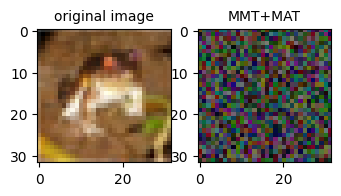

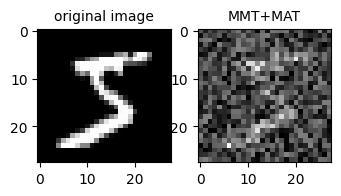

In [21]:
def show_mmt_mat(img,imgsize):
    fig = plt.figure(figsize=(10,10)) 
    ax1 = fig.add_subplot(1, 5, 1)  # 2行1列，第1个位置  
    plt.title('original image',fontsize=10)
    ax1.imshow(img,cmap='gray')
    
    img2mmt_mat = DLMT(imgsize=imgsize,max_v_add=256,max_v_mul=10).MMT_MAT(img)
    ax2 = fig.add_subplot(1, 5, 2)
    plt.title('MMT+MAT',fontsize=10)
    ax2.imshow(img2mmt_mat,cmap='gray')

for img, label in itertools.islice(iter(cifar10_train), 1):
    img = img.astype(np.uint8)
    show_mmt_mat(img,imgsize=(32,32,3))
for img, label in itertools.islice(iter(mnist_train), 1):
    img = img.astype(np.uint8)
    show_mmt_mat(img,imgsize=(28,28))